### Data Requirements:

This notebook requires the following files: 

1. `01_05_trips_weather_merged.parquet` — local path: `data/merged/01_05_trips_weather_merged.parquet` — Sciebo path: `data_parquet/merged/01_05_trips_weather_merged.parquet`

2. `Boundaries_Community_Areas_20260608.geojson` — local path: `data/geometry/Boundaries_Community_Areas_20260608.geojson` — Sciebo path: `data_parquet/geometry/Boundaries_Community_Areas_20260608.geojson`

Sample data is provided in the appropriate locations for testing purposes only. It will not produce meaningful results.

In [25]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [26]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: C:\Users\Yannick Herrmann\Documents\Uni\AAA\AAA_Project\AAA_TA_2026


In [27]:
file_path = "data/merged/01_05_trips_weather_merged.parquet"

df = pd.read_parquet(file_path)
df.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare,tips,...,rain,snowfall,snow_depth,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_100m,is_day,sunshine_duration,direct_radiation
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01,2025-01-01 00:15:00,758.0,2.93,8,8,9.75,0.0,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01,2025-01-01 00:15:00,1233.0,13.66,76,6,35.00,8.1,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0
2,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01,2025-01-01 00:15:00,985.0,3.22,8,7,55.00,0.0,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01,2025-01-01 00:15:00,652.0,3.24,22,7,11.67,4.0,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01,2025-01-01 00:15:00,803.0,6.09,8,3,17.50,0.0,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5369356 entries, 0 to 5369355
Data columns (total 39 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_id                     str           
 1   taxi_id                     str           
 2   trip_start_timestamp        datetime64[ns]
 3   trip_end_timestamp          datetime64[ns]
 4   trip_seconds                float64       
 5   trip_miles                  float64       
 6   pickup_community_area       int64         
 7   dropoff_community_area      int64         
 8   fare                        float64       
 9   tips                        float64       
 10  tolls                       float64       
 11  extras                      float64       
 12  trip_total                  float64       
 13  payment_type                str           
 14  company                     str           
 15  pickup_centroid_latitude    float64       
 16  pickup_centroid_longitude   f

In [29]:
df["start_hour"] = df["trip_start_timestamp"].dt.hour

In [31]:

areas = gpd.read_file("data/geometry/Boundaries_Community_Areas_20260608.geojson").to_crs(3857)

areas

,:id,:version,:created_at,:updated_at,area_numbe,community,area_num_1,shape_area,shape_len,geometry
0,row-m77e_pkv8.vjvf,rv-3hjp_vkhx~fqfx,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,1,ROGERS PARK,1,51259902.4506,34052.3975757,"MULTIPOLYGON (((-9757660.529 5160704.746, -975..."
1,row-u375_347e-y6q8,rv-tgcx_t7fr-nkkg,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,2,WEST RIDGE,2,98429094.8621,43020.6894583,"MULTIPOLYGON (((-9761010.933 5163898.616, -976..."
2,row-kgqf-m29p-99kg,rv-bag4-8zri.nvhu,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,3,UPTOWN,3,65095642.7289,46972.7945549,"MULTIPOLYGON (((-9756154.198 5154211.526, -975..."
3,row-2dpv_pk9x-zybp,rv-82s2~rb54~emuc,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,4,LINCOLN SQUARE,4,71352328.2399,36624.6030848,"MULTIPOLYGON (((-9759870.406 5157400.522, -975..."
4,row-37zy.7r75.56p7,rv-hrse.ahu7-rz4d,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,5,NORTH CENTER,5,57054167.85,31391.6697542,"MULTIPOLYGON (((-9759754.254 5150850.097, -975..."
...,...,...,...,...,...,...,...,...,...,...
72,row-3uma_gs6v_expc,rv-cj4p_x3rj.brzz,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,73,WASHINGTON HEIGHTS,73,79635752.8769,42222.598163,"MULTIPOLYGON (((-9755342.627 5120449.037, -975..."
73,row-rn7j_sh22-jf8y,rv-a49v.s4vy~pudv,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,74,MOUNT GREENWOOD,74,75584290.0209,48665.1305392,"MULTIPOLYGON (((-9762325.229 5117211.619, -976..."
74,row-fiv3~fa4r~zk9e,rv-vip3.c98b.9m2d,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,75,MORGAN PARK,75,91877340.6988,46396.419362,"MULTIPOLYGON (((-9756279.738 5113922.382, -975..."
75,row-wewr.7jx4_gctv,rv-awj9_vhn6~tvpk,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,76,OHARE,76,371835607.687,173625.98466,"MULTIPOLYGON (((-9777923.456 5158941.865, -977..."


In [32]:
# calculate demand per community area since coordinates are located at the centroid of the community areas
# calculating KDE for > 5 million rows individually would be too demanding
area_demand = (
    df.groupby("pickup_community_area")
      .size()
      .reset_index(name="trip_count")
)

area_centroids = (
    df.groupby("pickup_community_area")[["pickup_centroid_latitude", "pickup_centroid_longitude"]]
      .first()
      .reset_index()
)

area_demand = area_demand.merge(area_centroids, on="pickup_community_area")

## KDE Visualization

In [33]:
from scipy.stats import gaussian_kde

# implement KDE using weighted community area coordinates
xy = area_demand[["pickup_centroid_longitude", "pickup_centroid_latitude"]].values.T
weights = area_demand["trip_count"].values / area_demand["trip_count"].sum()

kde = gaussian_kde(xy, bw_method=0.1, weights=weights)

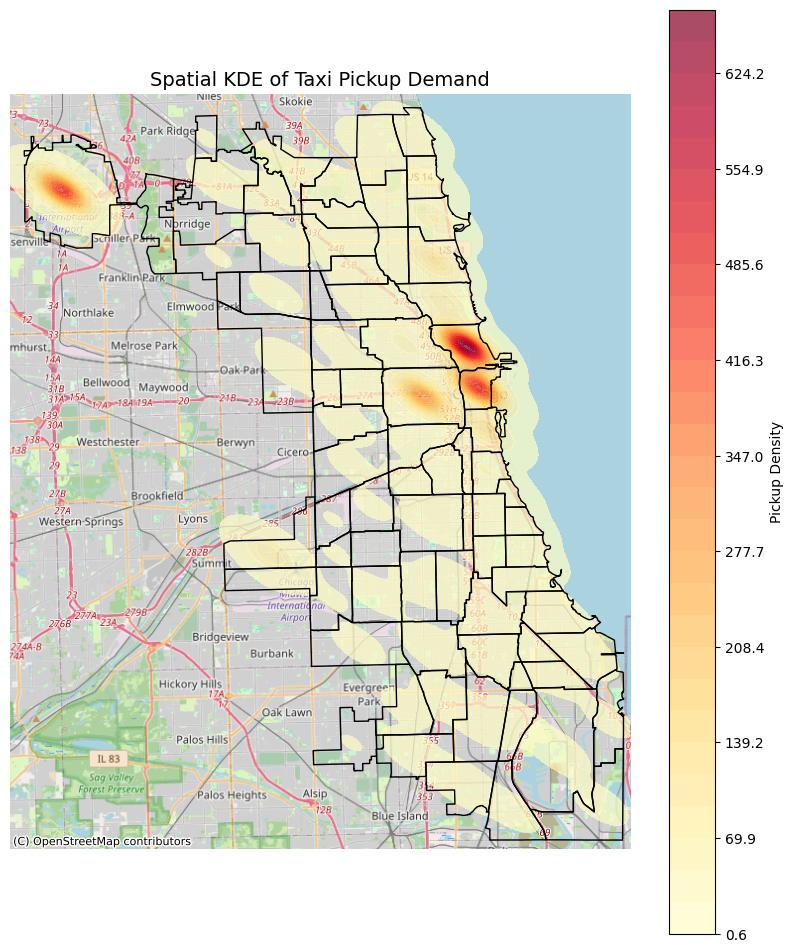

In [34]:
from shapely.geometry import Point
import contextily as cx

# evaluate KDE using an even grid over chicago
lon_min, lon_max = -87.95, -87.52
lat_min, lat_max = 41.64, 42.03

lon_grid = np.linspace(lon_min, lon_max, 300)
lat_grid = np.linspace(lat_min, lat_max, 300)
xx, yy = np.meshgrid(lon_grid, lat_grid)
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# convert the grid to mercator
gdf_grid = gpd.GeoDataFrame(
    geometry=[Point(lon, lat) for lon, lat in zip(xx.ravel(), yy.ravel())],
    crs="EPSG:4326"
).to_crs(epsg=3857)

xs = gdf_grid.geometry.x.values.reshape(xx.shape)
ys = gdf_grid.geometry.y.values.reshape(xx.shape)

# plot the kde distribution on the chicago map, including the community area shapes
fig, ax = plt.subplots(figsize=(10, 12))

# Highlight only the highest-density regions (top 30% of zz values)
levels = np.linspace(np.percentile(zz, 70), zz.max(), 30)

contour = ax.contourf(xs, ys, zz, levels=levels, cmap="YlOrRd", alpha=0.7)

plt.colorbar(contour, ax=ax, label= "Pickup Density")

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
areas.plot(ax = ax, facecolor="none", edgecolor="k")
ax.set_title("Spatial KDE of Taxi Pickup Demand", fontsize=14)
ax.set_axis_off()
plt.show()

Since the coordinates for each trip are the centroid coordinates of the corresponding community, instead of being exact coordinates, this visualization does not offer many new insights compared to the choropleth maps.

## Hotspots for different times of day

In [35]:
# create bins for different times of day
bins = {
    "Night (0–6)":         (0, 6),
    "Morning (6–12)":      (6, 12),
    "Afternoon (12–18)":   (12, 18),
    "Evening (18–24)":     (18, 24),
}

In [36]:

# compute demand and kde per time of day - bin
bin_demands = {}
bin_kdes = {}
for label, (h_start, h_end) in bins.items():
    subset = df[(df["start_hour"] >= h_start) & (df["start_hour"] < h_end)]

    area_demand = (
        subset.groupby("pickup_community_area")
        .size()
        .reset_index(name="trip_count")
    )

    area_centroids = (
        subset.groupby("pickup_community_area")[["pickup_centroid_latitude", "pickup_centroid_longitude"]]
        .first()
        .reset_index()
    )

    area_demand = area_demand.merge(area_centroids, on="pickup_community_area")
    bin_demands[label] = area_demand

    xy = area_demand[["pickup_centroid_longitude", "pickup_centroid_latitude"]].values.T
    weights = area_demand["trip_count"].values / area_demand["trip_count"].sum()

    bin_kdes[label] = gaussian_kde(xy, bw_method=0.1, weights=weights)

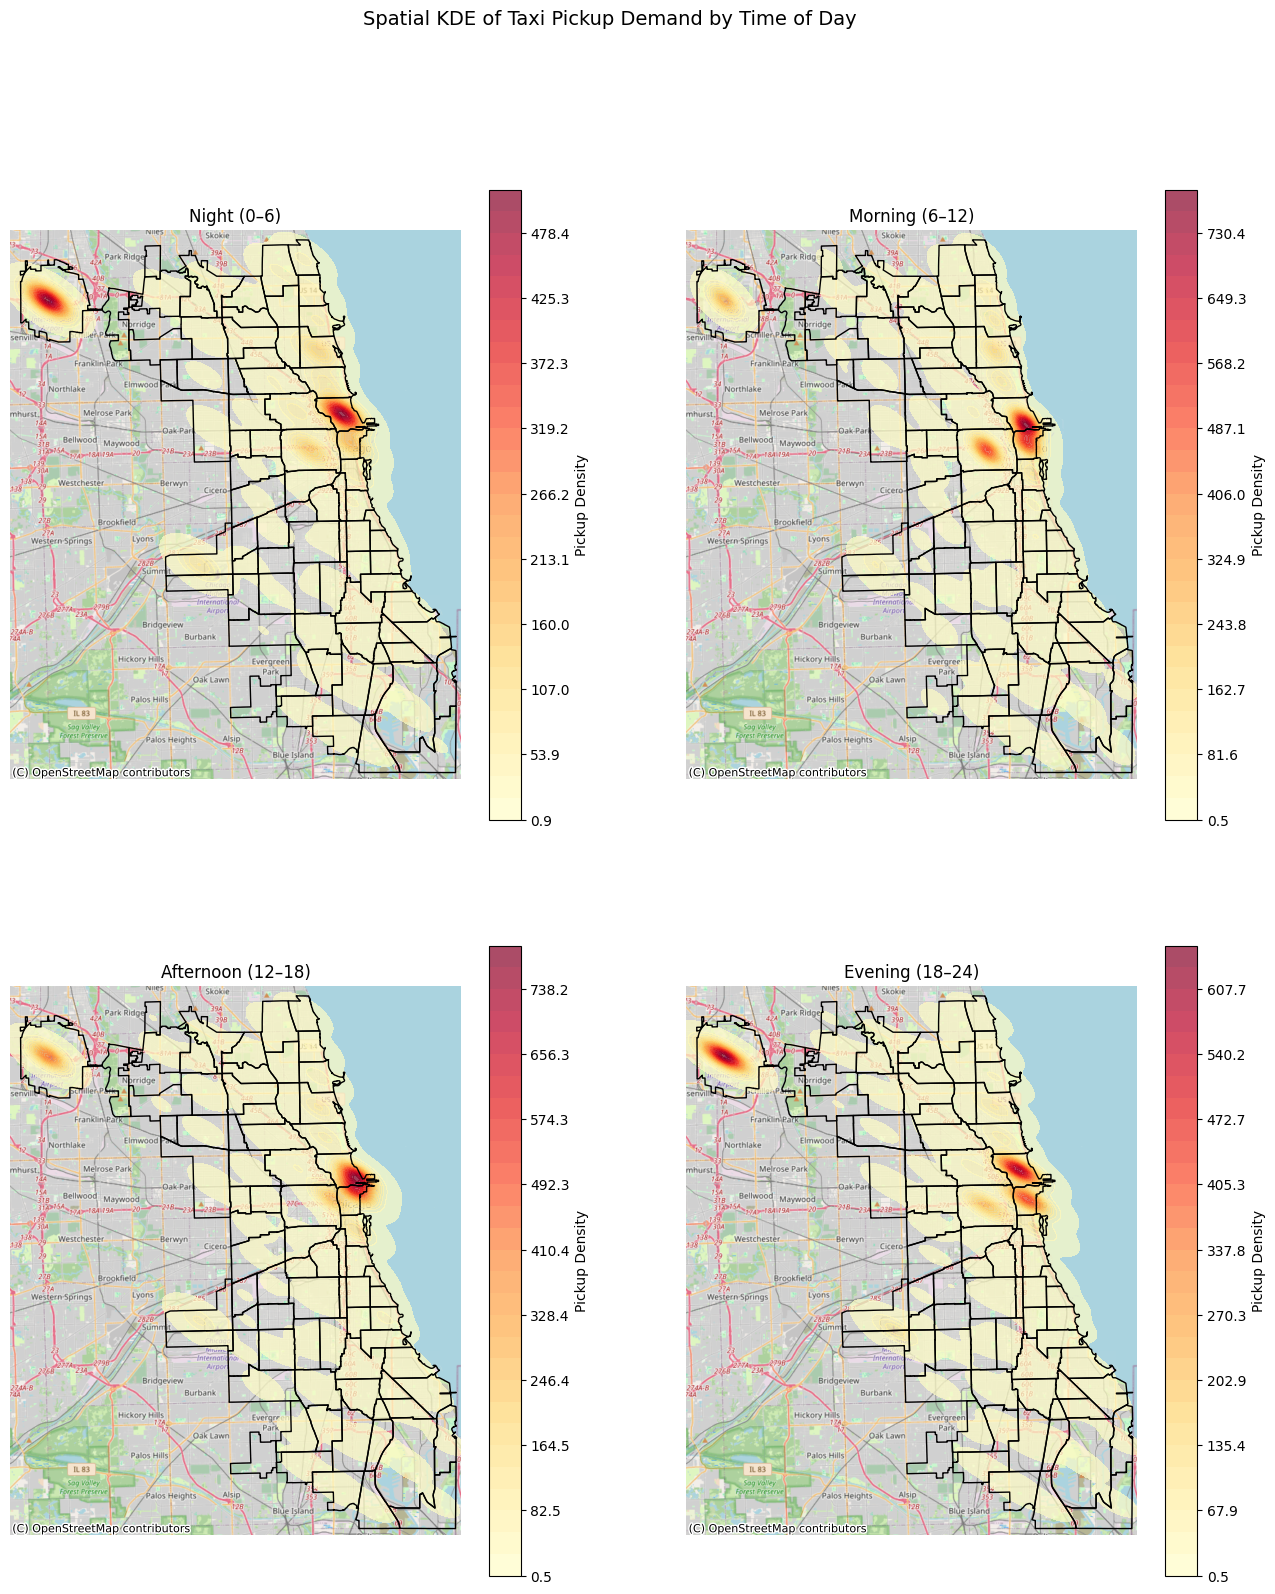

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 18))

# plot the KDE visualisation per time bin, including community area shapes
for ax, label in zip(axes.flat, bins.keys()):

    # compute the zz value per bin
    zz = bin_kdes[label](np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    # Highlight only the highest-density regions (top 30% of zz values)
    levels = np.linspace(np.percentile(zz, 70), zz.max(), 30)

    contour = ax.contourf(xs, ys, zz, levels=levels, cmap="YlOrRd", alpha=0.7)

    plt.colorbar(contour, ax=ax, label= "Pickup Density")

    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
    areas.plot(ax = ax, facecolor="none", edgecolor="k")
    ax.set_axis_off()
    ax.set_title(label)
    
plt.suptitle("Spatial KDE of Taxi Pickup Demand by Time of Day", fontsize=14)

plt.show()